# Notebook 3: Análisis de regulones

La libreta usa el objeto integrado `02_SCENIC_Seurat_integrated_adata.h5ad` generado en la Notebook 2 a partir de los datos de pySCENIC y Seurat.

Objetivos:
- Calcular RSS para los clusters de Seurat (`functional_ann2`) y pySCENIC (`SCENIC_cluster_L1` y `SCENIC_cluster_L2`). 
- Graficar curvas de ranking de RSS para los regulones de cada grupo.
- Graficar heatmaps de RSS para los regulones de cada grupo.
- Graficar heatmaps de contingencia celular entre clusters de pySCENIC y de Seurat.

El análisis parte de:
- actividad continua de regulones (`AUC`, la matriz principal del objeto AnnData obtenida de AUCell)
- embeddings y clusters SCENIC y Seurat
- metadatos experimentales y anotaciones de Seurat

RSS: para cada regulón y grupo celular se compara la distribución de AUC del regulón con una distribución ideal concentrada en ese grupo mediante distancia de Jensen-Shannon. Valores mayores indican mayor especificidad del regulón para el grupo.

Otros análisis futuros:
- RSS, curvas y heatmaps para las anotaciones automáticas
- Comparar actividad regulónica en tres contrastes:
   - HA15 vs Control.
   - HA15 vs Control dentro de HIV+.
   - HIV+ vs HIV− dentro de HA15.
- Graficar redes de regulones
- Enriquecimiento de rutas y ontología?
- Preparar loom para exportar y visualizar en SCope

Adaptado de:
- `pySCENIC - Integration with scanpy.ipynb`
- `pySCENIC - Create loom file.ipynb`
- `SCENICprotocol - PBMC10k_downstream-analysis.ipynb`
- flujo general del protocolo SCENIC / pySCENIC

Esta libreta está adaptada a un dataset de HA15 vs Control en un modelo de latencia del VIH-1 con células CD4+ humanas (GSE210824).

In [17]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import loompy as lp
from pyscenic.rss import regulon_specificity_scores
from pyscenic.plotting import plot_rss
import seaborn as sns

# Compatibilidad pyscenic con NumPy moderno
if not hasattr(np, "float"):
    np.float = float

from pathlib import Path
from scipy import sparse
from collections import OrderedDict

sc.settings.set_figure_params(dpi=100, facecolor="white")
sns.set_theme(style="whitegrid")

## 1. Carga del objeto integrado

- Definir rutas

In [2]:
BASE = Path("/root/TFM/HA15_GSE210824")
PROC = BASE / "proc_data"
RESULTS = BASE / "results"
FIGURES = RESULTS / "figures"
TABLES = RESULTS / "tables"

adata_path = PROC / "02_SCENIC_Seurat_integrated_adata.h5ad"
seurat_loom_path = PROC / "ann.loom"

- Calcular y añadir el metadato de estado viral

In [3]:
adata = sc.read_h5ad(adata_path)

with lp.connect(str(seurat_loom_path), mode="r", validate=False) as lf:
    genes = pd.Index(lf.ra["Gene"].astype(str))
    cell_ids = pd.Index(lf.ca["CellID"].astype(str), name="CellID")

    tat_rows = np.where(genes == "Tat")[0]
    rev_rows = np.where(genes == "Rev")[0]

    print("Tat rows:", tat_rows)
    print("Rev rows:", rev_rows)

    tat_counts = lf[tat_rows, :].sum(axis=0)
    rev_counts = lf[rev_rows, :].sum(axis=0)

hiv_status = pd.Series(
    np.where((tat_counts > 0) | (rev_counts > 0), "HIV+", "HIV-"),
    index=cell_ids,
    name="HIV_status"
)

adata.obs["HIV_status"] = hiv_status.loc[adata.obs_names].values

print(adata.obs["HIV_status"].value_counts())

Tat rows: [17750]
Rev rows: [15077]
HIV_status
HIV-    4284
HIV+    1028
Name: count, dtype: int64


- Convertir la matriz AUC de AnnData en un array de NumPy, y este en un dataframe. Metadatos.

In [4]:
X = adata.X.toarray() if sparse.issparse(adata.X) else np.asarray(adata.X)
auc_df = pd.DataFrame(X, index=adata.obs_names, columns=adata.var_names).astype(float)
meta = adata.obs.copy()

## 2. RSS y curvas de ranking (funciones de pySCENIC)


- Calculamos RSS

In [5]:
rss_functional_ann2 = regulon_specificity_scores(auc_df,meta["functional_ann2"].astype(str))
print(rss_functional_ann2.shape)
print(rss_functional_ann2.index.tolist())
print(rss_functional_ann2.columns[:5])

rss_scenic_L1 = regulon_specificity_scores(auc_df,meta["SCENIC_cluster_L1"].astype(str))
print(rss_scenic_L1.shape)
print(rss_scenic_L1.index.tolist())
print(rss_scenic_L1.columns[:5])

rss_scenic_L2 = regulon_specificity_scores(auc_df,meta["SCENIC_cluster_L2"].astype(str))
print(rss_scenic_L2.shape)
print(rss_scenic_L2.index.tolist())
print(rss_scenic_L2.columns[:5])

(11, 276)
['Prolif G2/M', 'Prolif S', 'Tem Th2', 'mTreg Th1/Th2-like', 'Act (reprog)', 'Tem/Teff CTL', 'Act (replic)', 'Tem Th1/Treg', 'Act (Th1)', 'mTreg Th1-like', 'Tem CTL']
Index(['AHR(+)', 'ARID3A(+)', 'ARNT(+)', 'ARNTL2(+)', 'ASCL1(+)'], dtype='object')
(4, 276)
['3', '1', '0', '2']
Index(['AHR(+)', 'ARID3A(+)', 'ARNT(+)', 'ARNTL2(+)', 'ASCL1(+)'], dtype='object')
(8, 276)
['6', '1', '0', '3', '4', '2', '5', '7']
Index(['AHR(+)', 'ARID3A(+)', 'ARNT(+)', 'ARNTL2(+)', 'ASCL1(+)'], dtype='object')


- curva de rankings RSS para un cluster/anotación celular

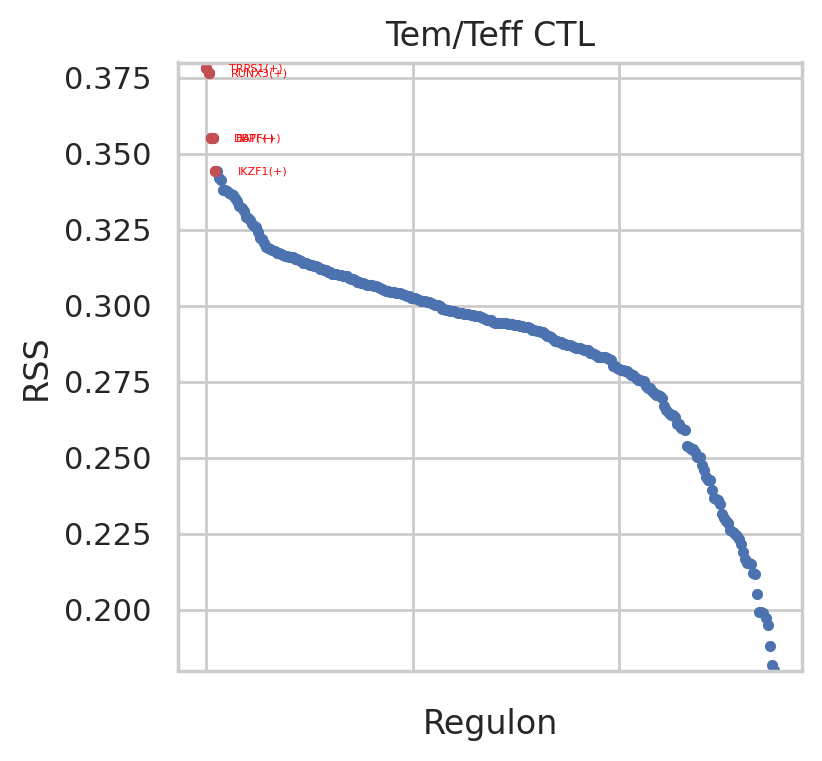

In [6]:
plot_rss(rss_functional_ann2, cell_type="Tem/Teff CTL", top_n=5)

- curva de rankings RSS para todos los clusters/anotaciones celulares de Seurat

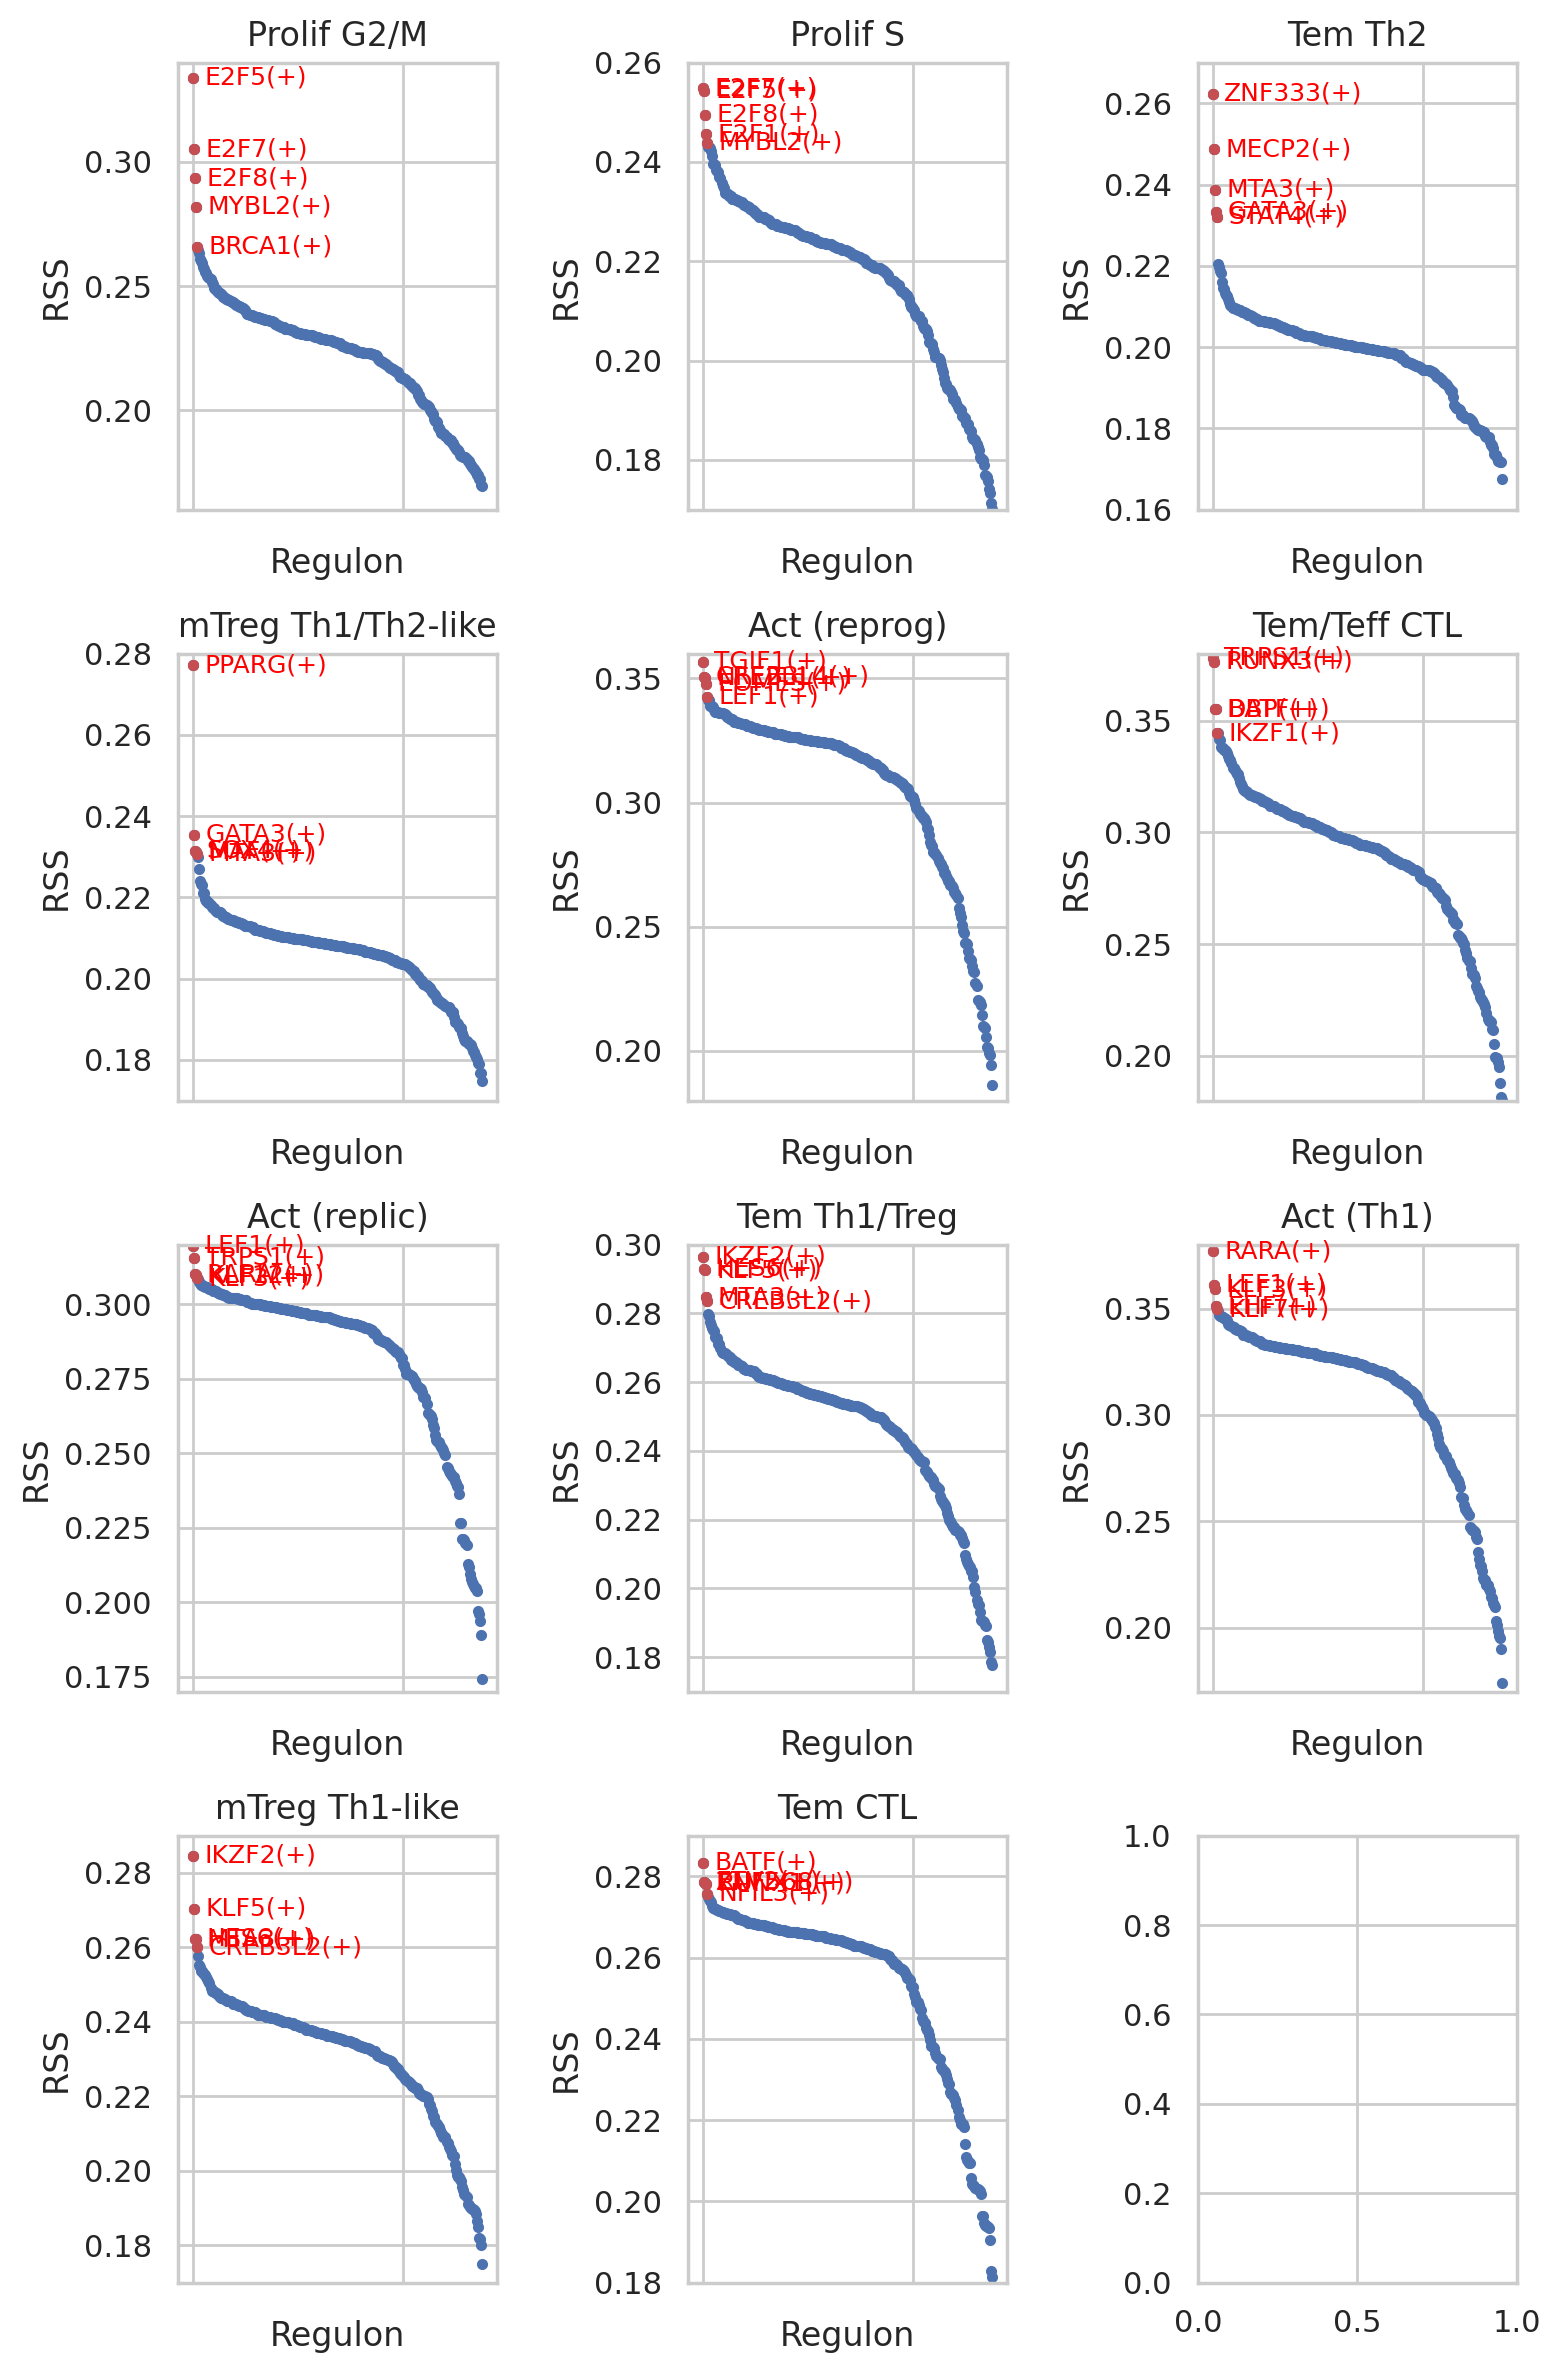

In [7]:
fig, axes = plt.subplots(4, 3, figsize=(8, 12))
axes = axes.flatten()

for ax, group in zip(axes, rss_functional_ann2.index.astype(str)):
    plot_rss(rss_functional_ann2, cell_type=group, top_n=5, ax=ax)
    ax.set_title(f"{group}")

    for coll in ax.collections: coll.set_sizes([45])
    for txt in ax.texts: txt.set_fontsize(9)
    
plt.tight_layout()
plt.savefig(FIGURES / "03_RSS_curves_seurat.png", dpi=300, bbox_inches="tight")
plt.show()

- curva de rankings RSS para todos los clusters L1 de pySCENIC

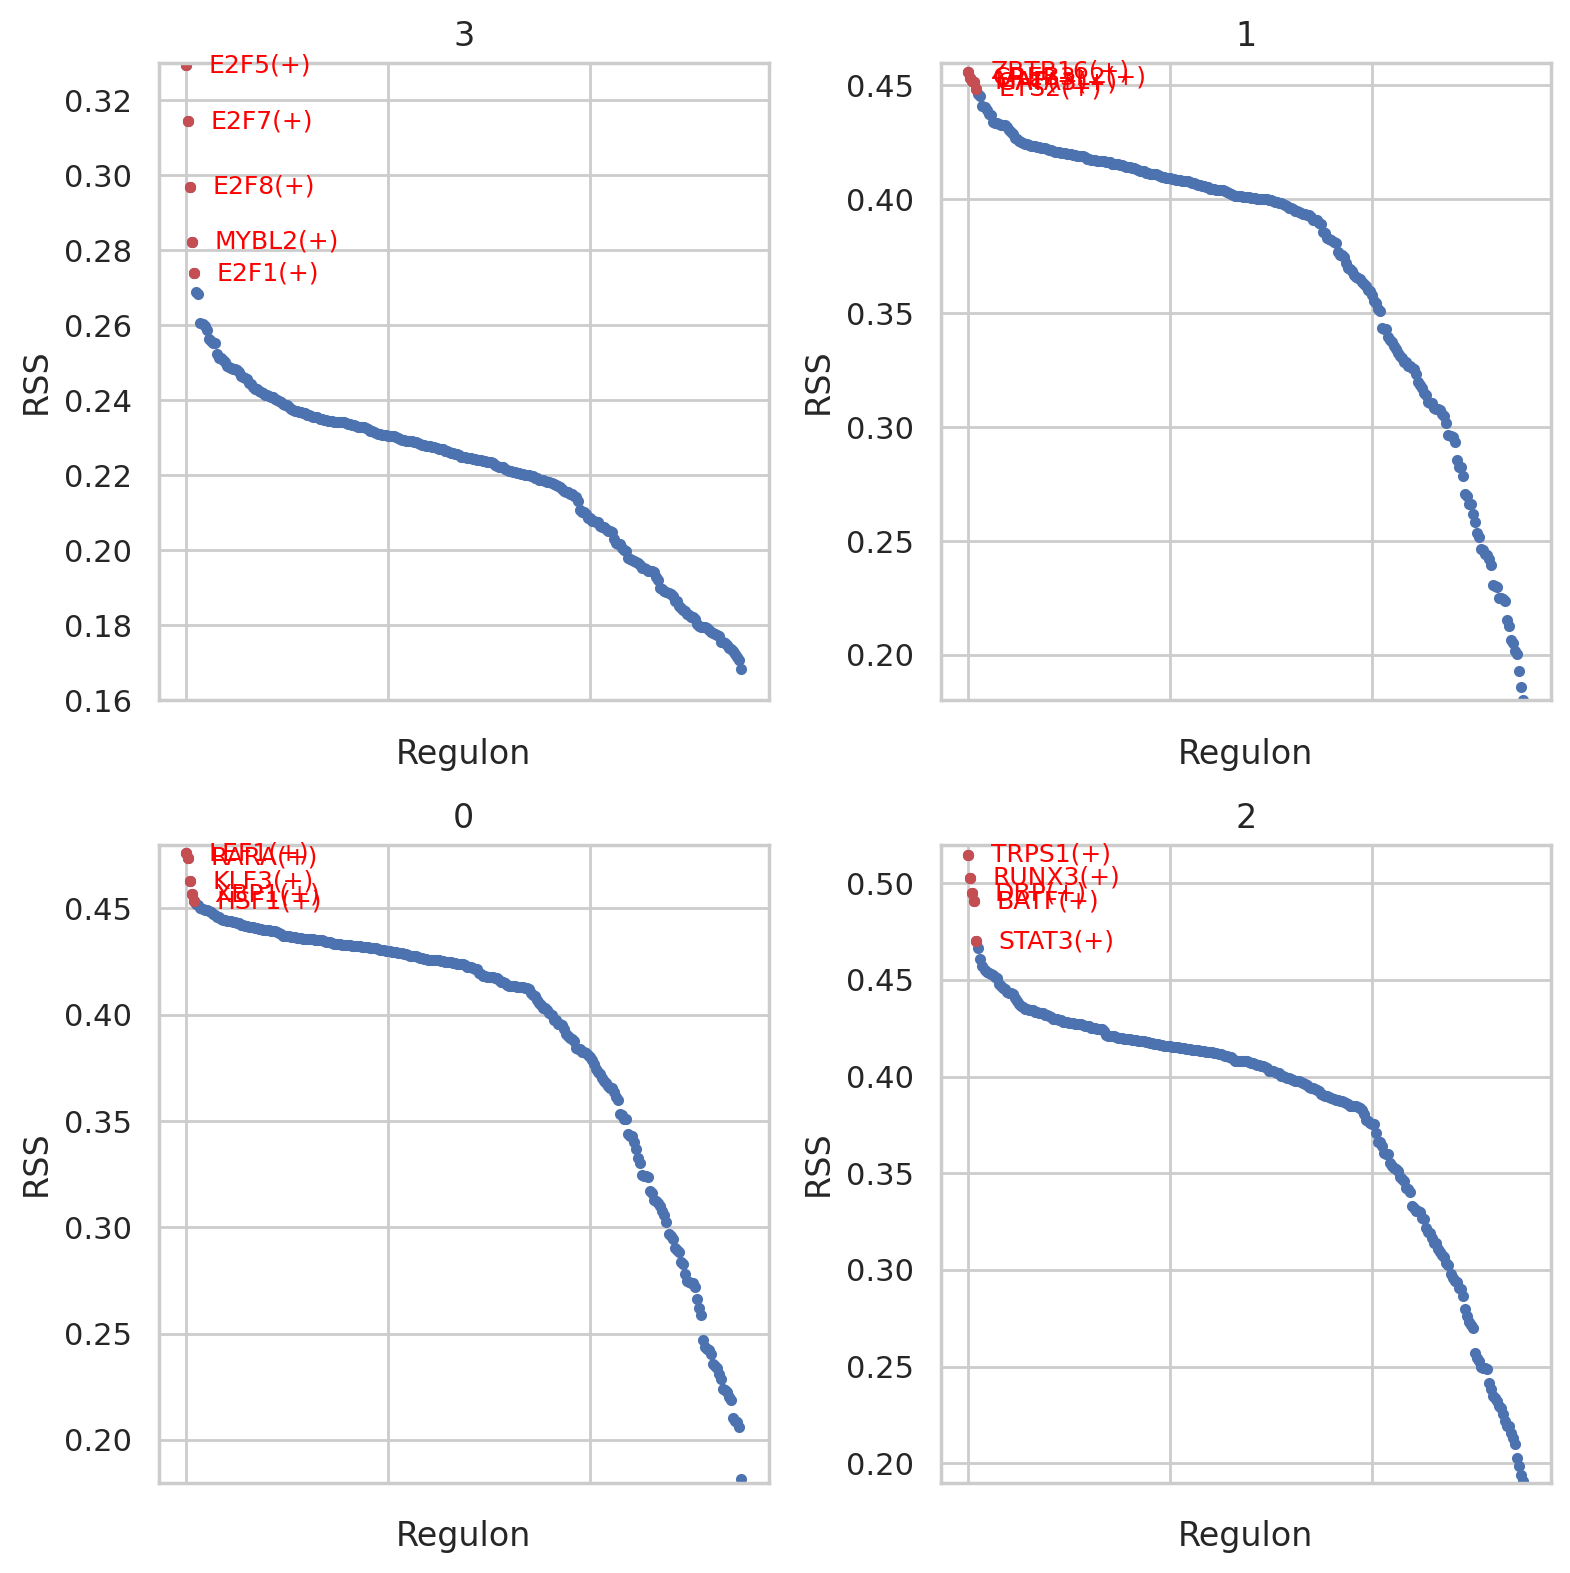

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for ax, group in zip(axes, rss_scenic_L1.index.astype(str)):
    plot_rss(rss_scenic_L1, cell_type=group, top_n=5, ax=ax)
    ax.set_title(f"{group}")

    for coll in ax.collections: coll.set_sizes([45])
    for txt in ax.texts: txt.set_fontsize(9)
    
plt.tight_layout()
plt.savefig(FIGURES / "03_RSS_curves_scenic_L1.png", dpi=300, bbox_inches="tight")
plt.show()

- curva de rankings RSS para todos los clusters L2 de pySCENIC

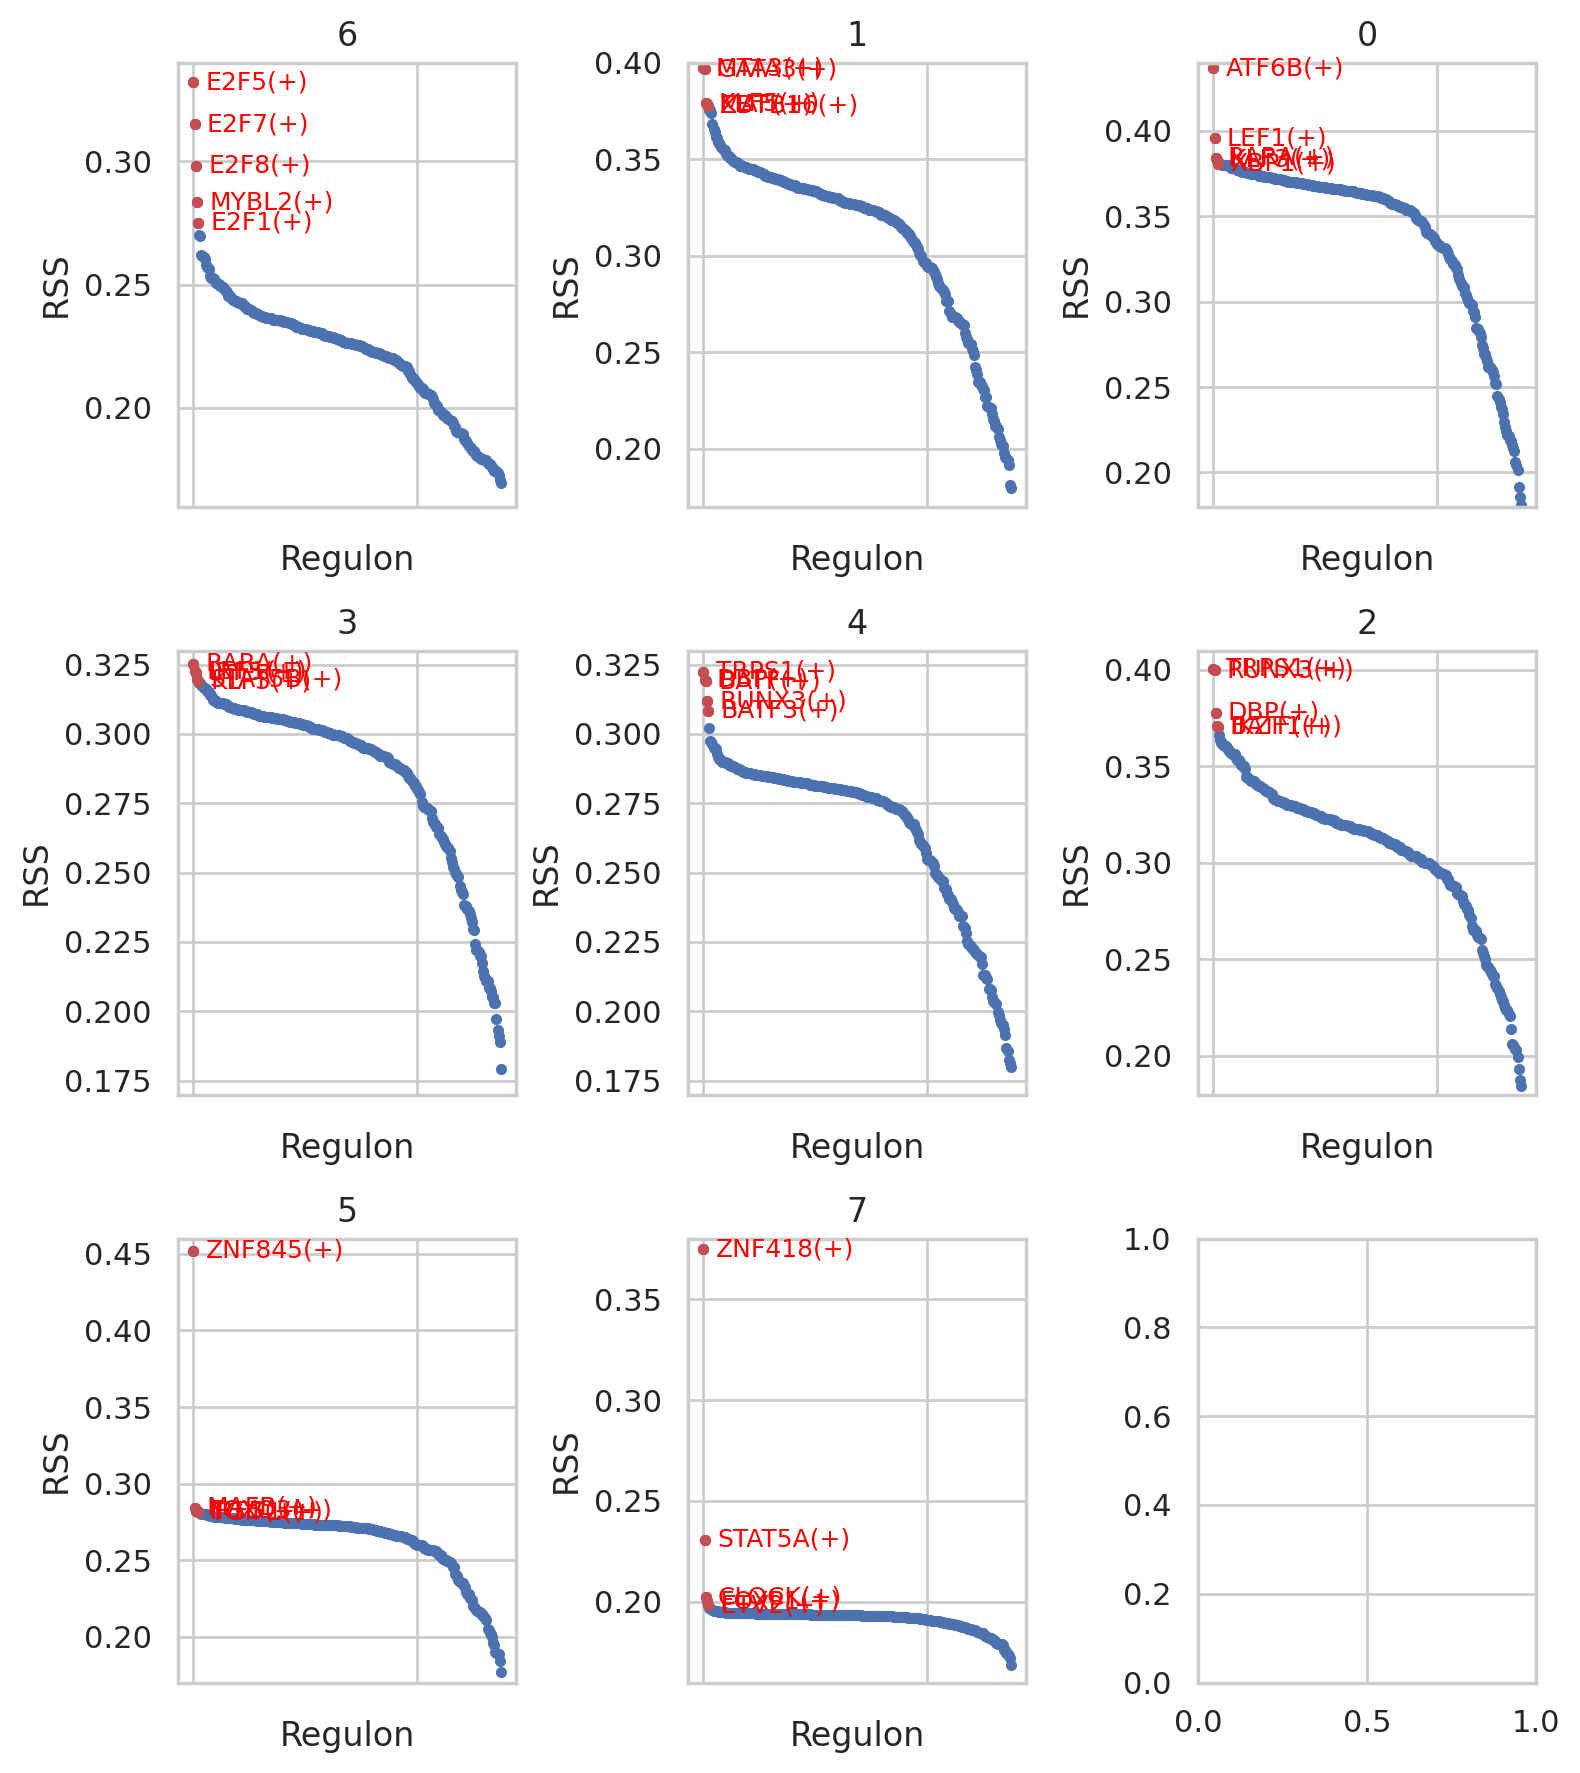

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(8, 9))
axes = axes.flatten()

for ax, group in zip(axes, rss_scenic_L2.index.astype(str)):
    plot_rss(rss_scenic_L2, cell_type=group, top_n=5, ax=ax)
    ax.set_title(f"{group}")

    for coll in ax.collections: coll.set_sizes([45])
    for txt in ax.texts: txt.set_fontsize(9)
    
plt.tight_layout()
plt.savefig(FIGURES / "03_RSS_curves_scenic_L2.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Heatmaps de RSS

- HM grandes

In [10]:
def plot_rss_heatmap(rss_df, out_prefix, top_n_per_group=5, cmap="viridis"):
    labels = meta[out_prefix].loc[auc_df.index].astype(str)
    groups = list(labels.unique())

    # Seleccionar top regulones por subpoblación
    top_regs = []

    for group in rss_df.index:
        regs = (rss_df.loc[group].sort_values(ascending=False).head(top_n_per_group).index.tolist())
        top_regs.extend(regs)
    
    # Mantener regulones únicos respetando el orden de aparición
    top_regulons_unique = list(OrderedDict.fromkeys(top_regs))
    rss_heat = rss_df.loc[:, top_regulons_unique].T

    plt.figure(figsize=(max(9, 0.7 * rss_heat.shape[1]), max(8, 0.28 * rss_heat.shape[0])))
    sns.heatmap(rss_heat, cmap="viridis", linewidths=0.2, linecolor="white")
    
    plt.title(f"RSS de regulones por {out_prefix}")
    plt.xlabel(out_prefix)
    plt.ylabel("Regulón")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()
    return rss_heat

- HM compactos

In [11]:
def plot_rss_heatmap2(rss_df, out_prefix, top_n_per_group=5, cmap="viridis"):
    top_regs = []

    for group in rss_df.index:
        regs = (rss_df.loc[group].sort_values(ascending=False).head(top_n_per_group).index.tolist())
        top_regs.extend(regs)

    # Mantener regulones únicos respetando orden de aparición
    top_regs = list(OrderedDict.fromkeys(top_regs))

    # Matriz horizontal: filas = grupos, columnas = regulones
    heat = rss_df.loc[:, top_regs]
    heat.columns = heat.columns.astype(str)
    
    fig, ax = plt.subplots(figsize=(max(10, 0.35 * heat.shape[1]), max(4, 0.45 * heat.shape[0])))
    sns.heatmap(heat, cmap=cmap, ax=ax)

    ax.set_title(out_prefix)
    ax.set_xlabel("Regulón")
    ax.set_ylabel("Grupo")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    fig.tight_layout()
    plt.show()
    plt.close(fig)
    return heat

- HM de clusters Seurat

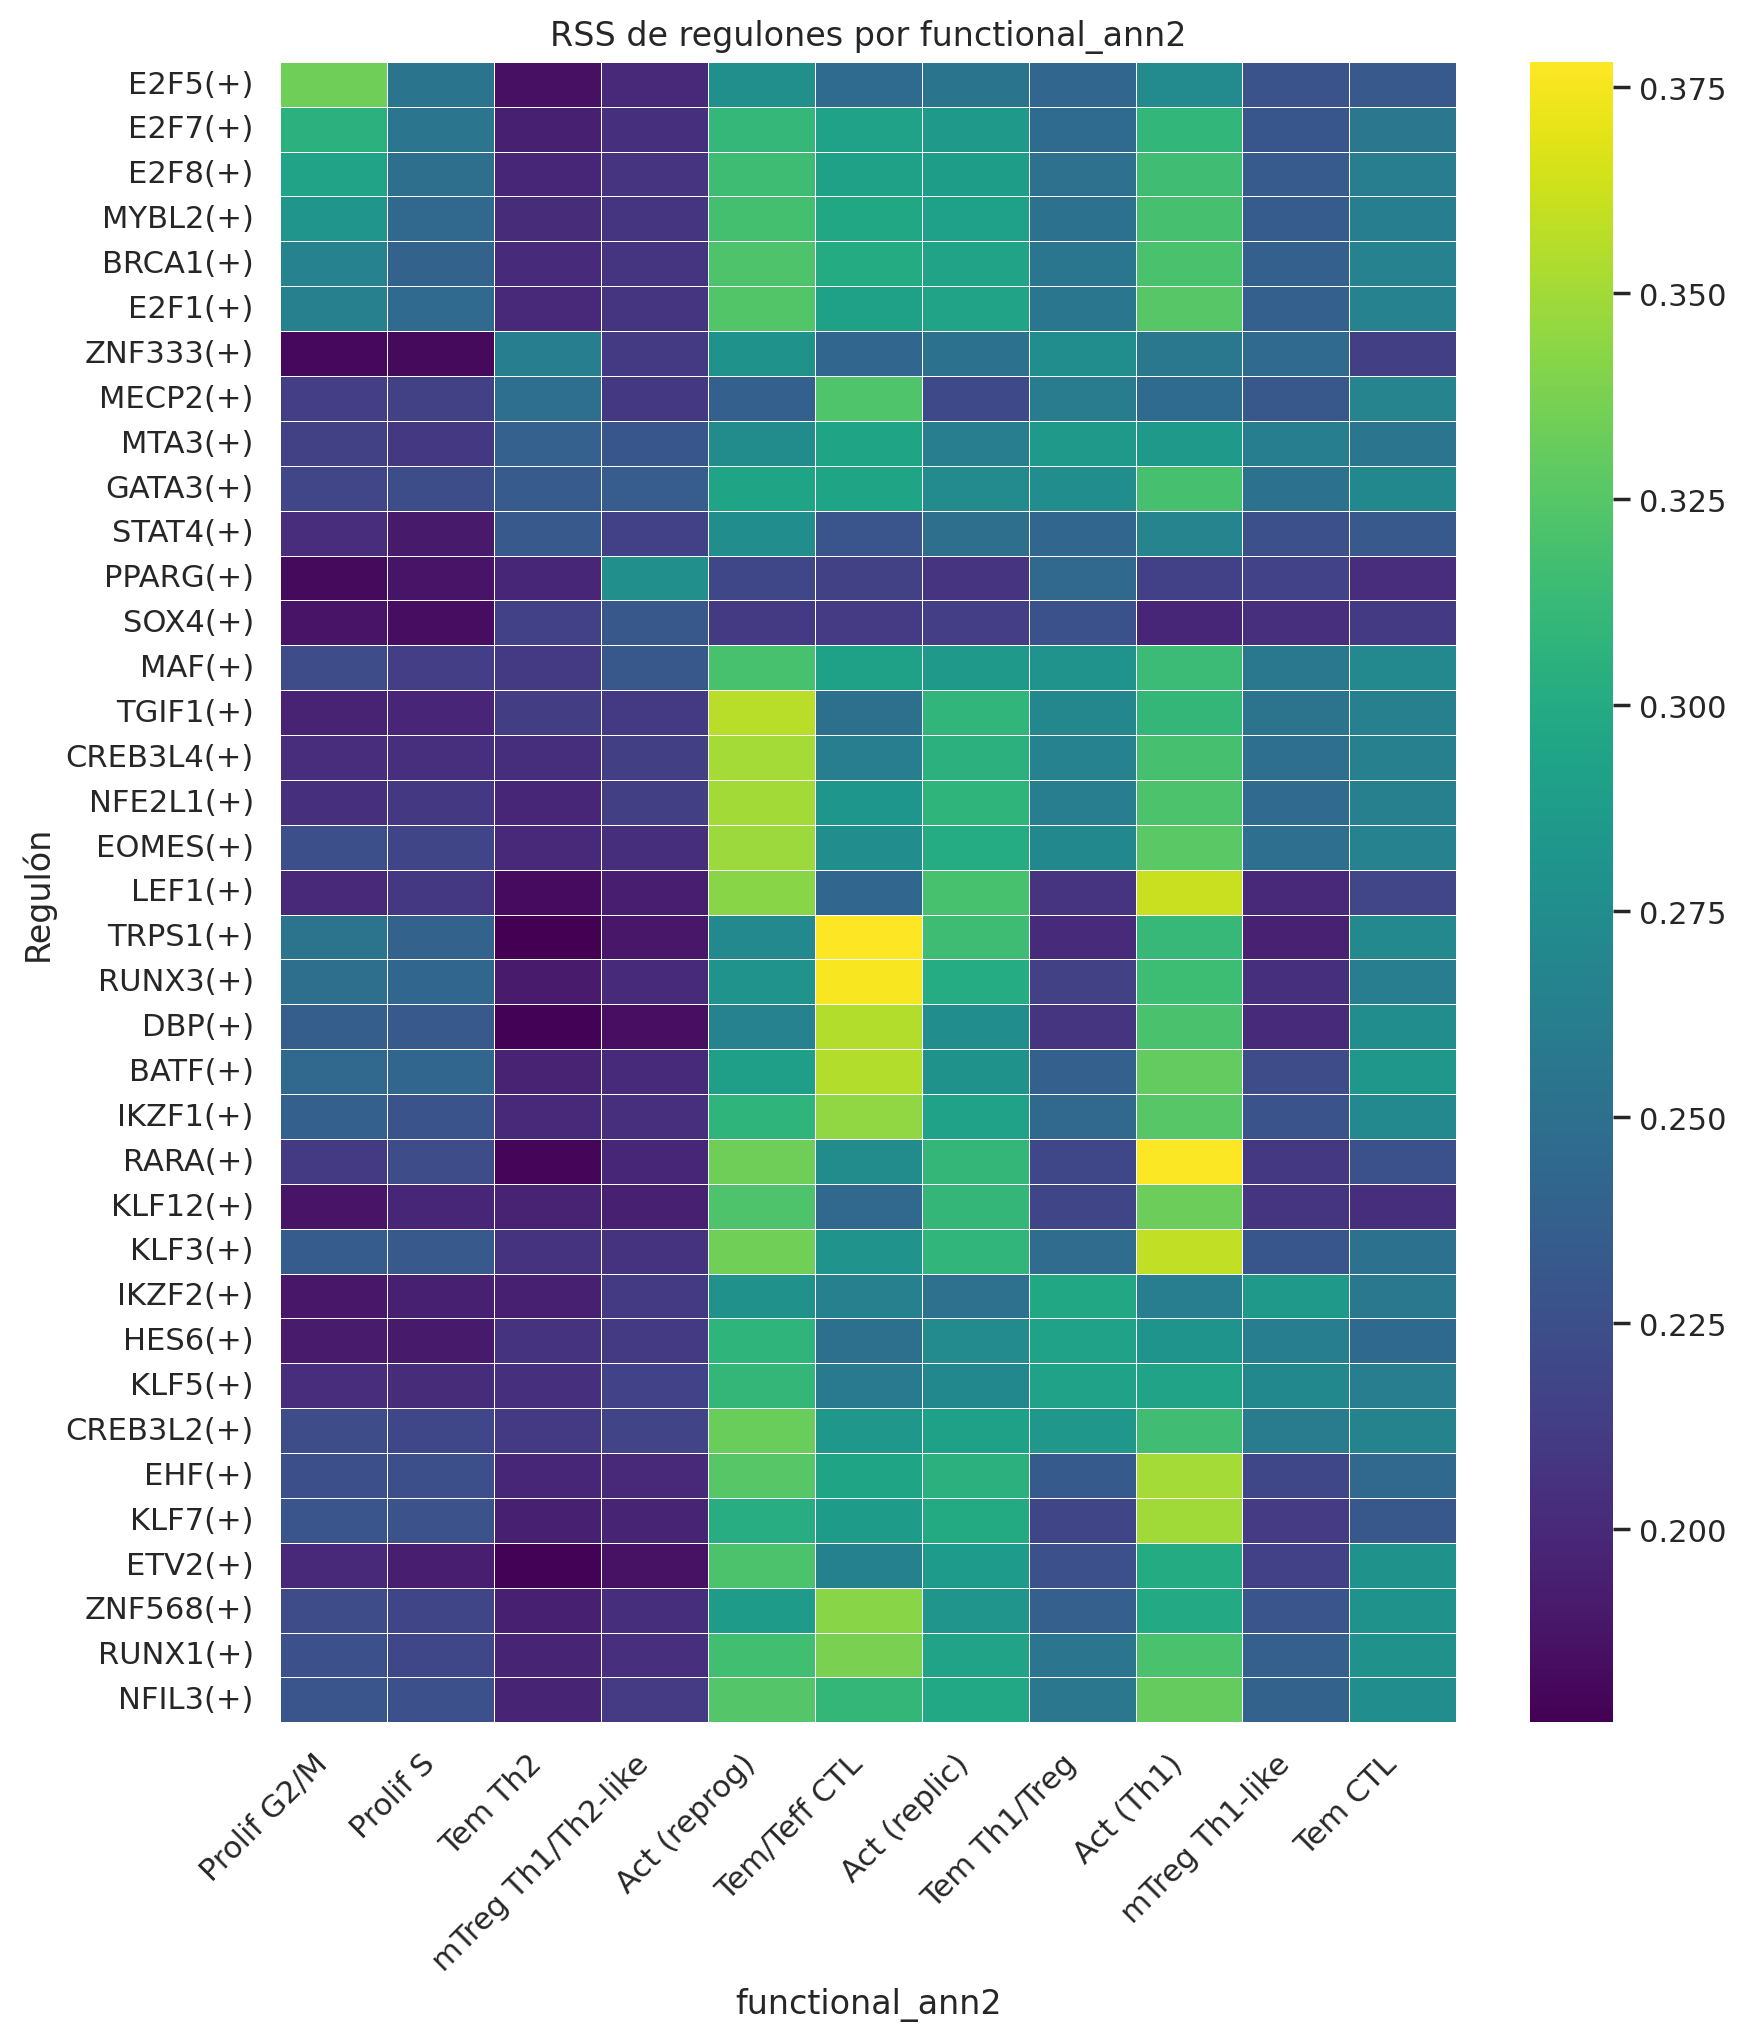

<Figure size 400x400 with 0 Axes>

In [12]:
plot_rss_heatmap(rss_functional_ann2, out_prefix="functional_ann2", top_n_per_group=5)
plt.savefig(FIGURES / "03_RSS_HM_Seurat.png",dpi=300,bbox_inches="tight")

- HM de clusters SCENIC L1

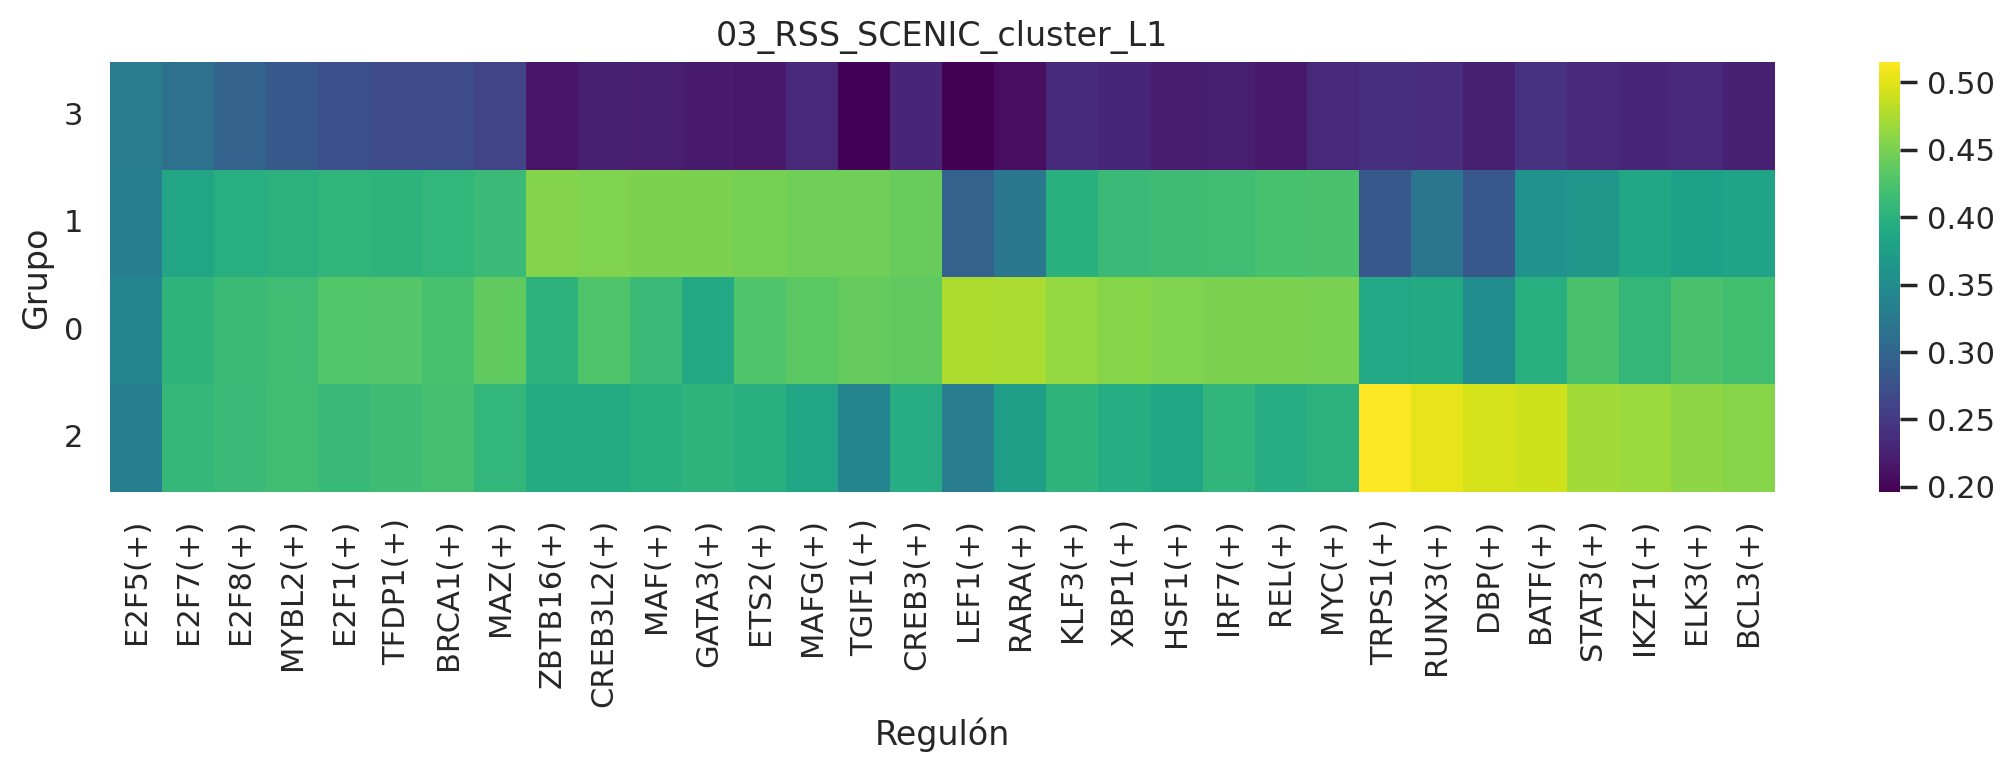

<Figure size 400x400 with 0 Axes>

In [13]:
# Heatmap RSS por SCENIC_cluster_L1
plot_rss_heatmap2(rss_scenic_L1, out_prefix="03_RSS_SCENIC_cluster_L1", top_n_per_group=8)
plt.savefig(FIGURES / "03_RSS_HM_SCENIC_L1.png",dpi=300,bbox_inches="tight")

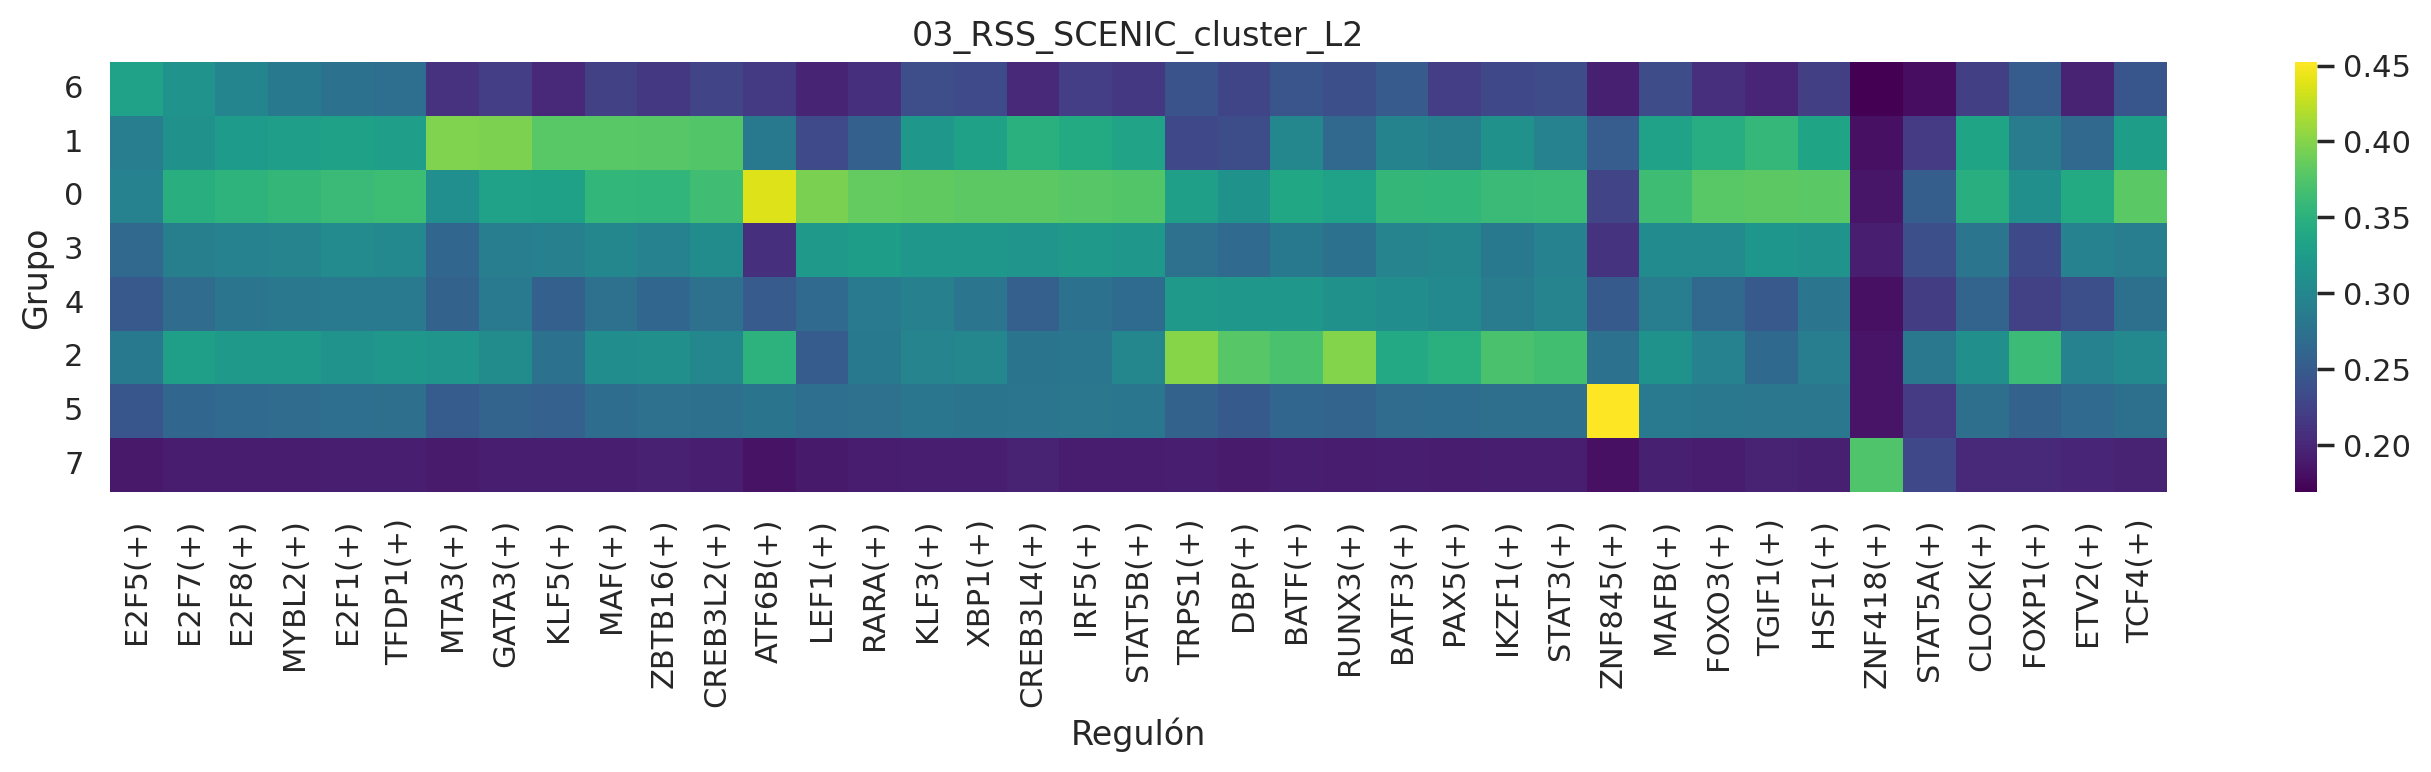

<Figure size 400x400 with 0 Axes>

In [14]:
plot_rss_heatmap2(rss_scenic_L2, out_prefix="03_RSS_SCENIC_cluster_L2", top_n_per_group=6,)
plt.savefig(FIGURES / "03_RSS_HM_SCENIC_L2.png",dpi=300,bbox_inches="tight")

## 4. Heatmaps de contingencia clusters Seurat-pySCENIC

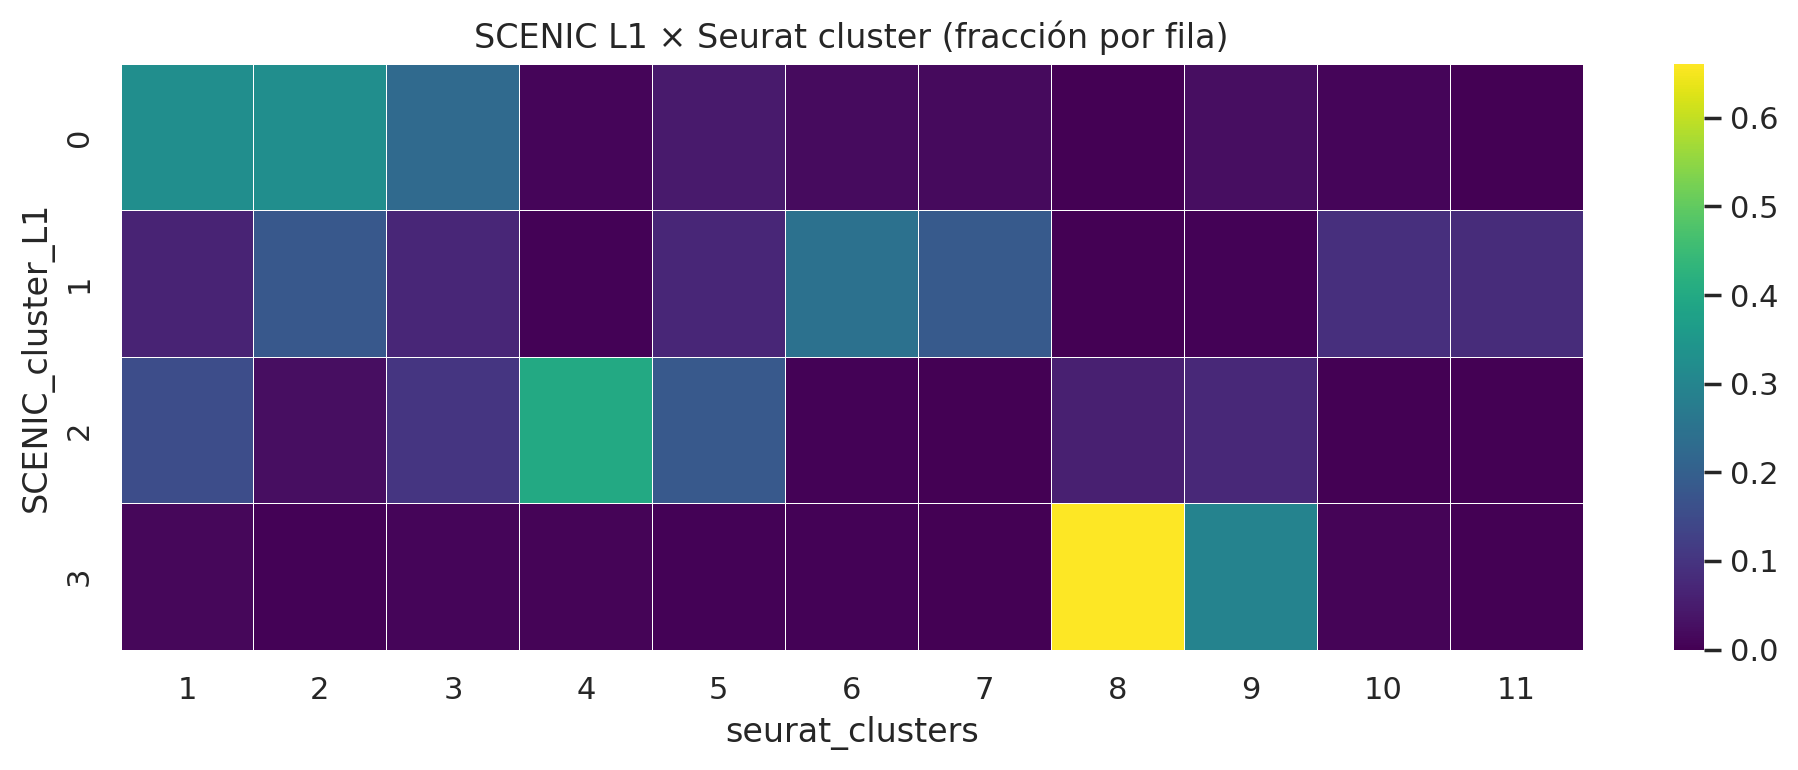

In [15]:
contingency_l1 = pd.crosstab(meta["SCENIC_cluster_L1"], meta["seurat_clusters"])
contingency_l1_row_frac = contingency_l1.div(contingency_l1.sum(axis=1), axis=0)

plt.figure(figsize=(10, 4))
sns.heatmap(contingency_l1_row_frac, cmap="viridis", linewidths=0.2)
plt.title("SCENIC L1 × Seurat cluster (fracción por fila)")
plt.xlabel("seurat_clusters")
plt.ylabel("SCENIC_cluster_L1")
plt.tight_layout()
plt.savefig(FIGURES / "03_SCENIC_L1_vs_Seurat_cluster_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

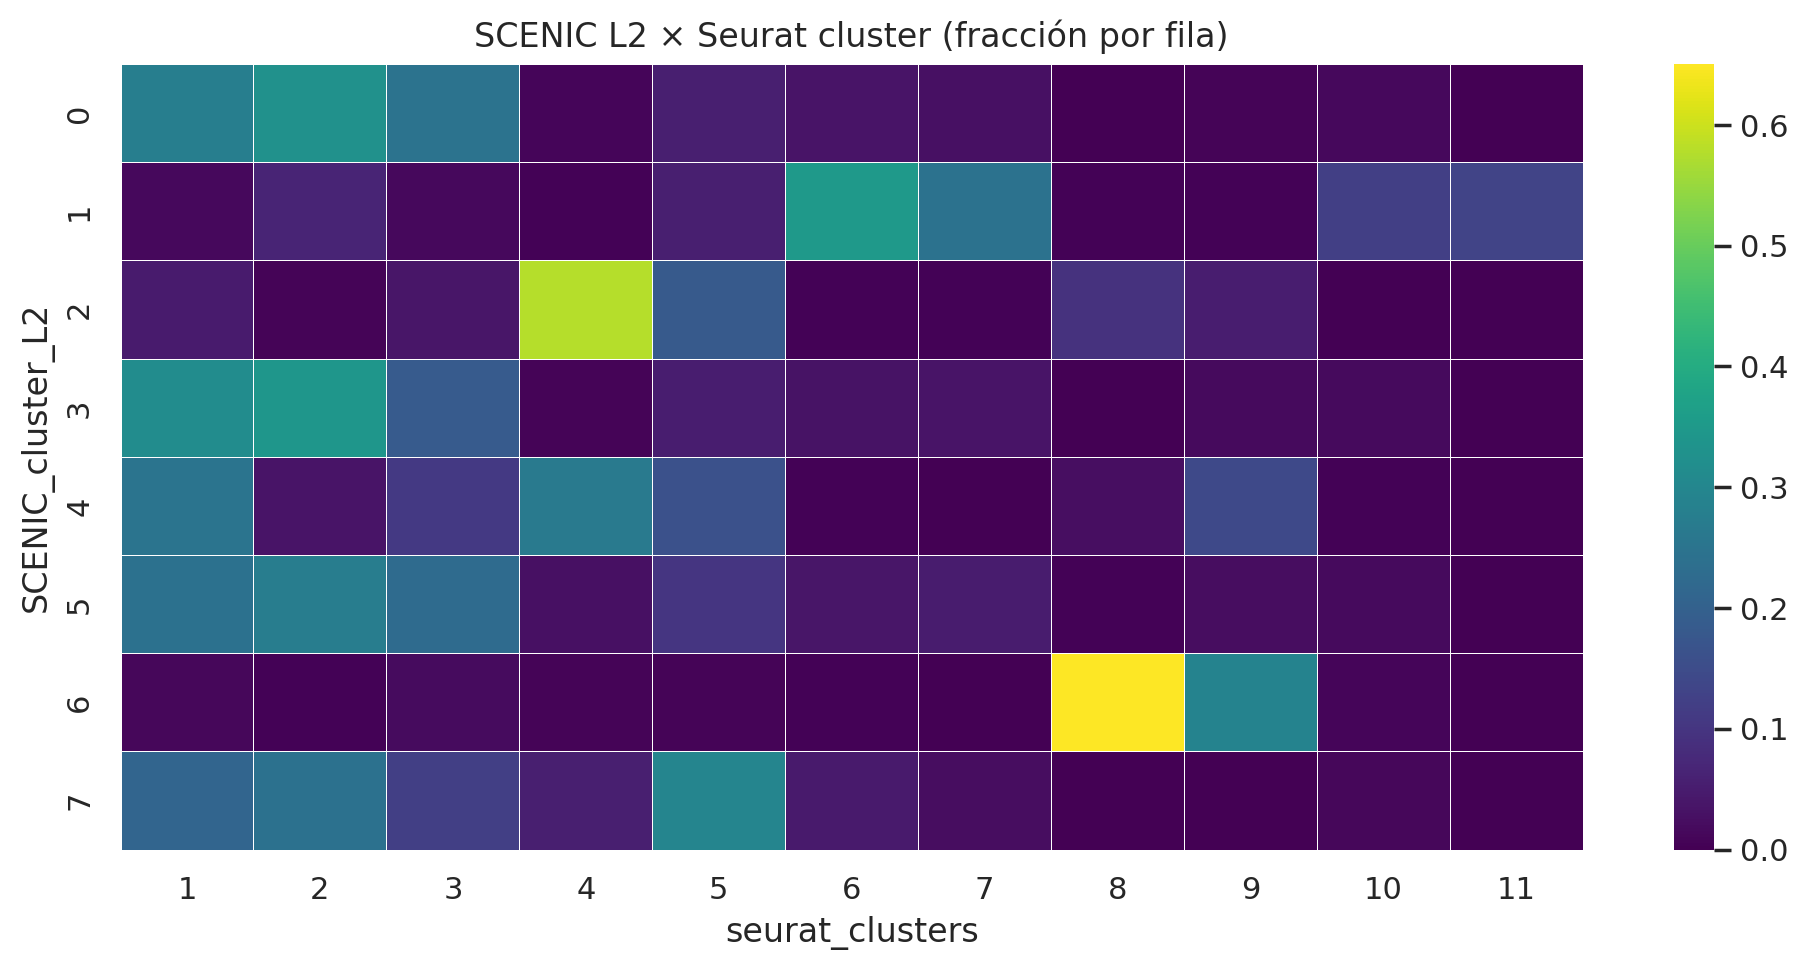

In [18]:
contingency_l2 = pd.crosstab(meta["SCENIC_cluster_L2"], meta["seurat_clusters"])
contingency_l2.to_csv(TABLES / "03_SCENIC_L2_vs_Seurat_cluster_contingency.tsv", sep="\t")

contingency_l2_row_frac = contingency_l2.div(contingency_l2.sum(axis=1), axis=0)
contingency_l2_row_frac.to_csv(TABLES / "03_SCENIC_L2_vs_Seurat_cluster_row_fraction.tsv", sep="\t")

plt.figure(figsize=(10, 5))
sns.heatmap(contingency_l2_row_frac, cmap="viridis", linewidths=0.2)
plt.title("SCENIC L2 × Seurat cluster (fracción por fila)")
plt.xlabel("seurat_clusters")
plt.ylabel("SCENIC_cluster_L2")
plt.tight_layout()
plt.savefig(FIGURES / "03_SCENIC_L2_vs_Seurat_cluster_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()